In [3]:
%load_ext autoreload
%autoreload 2

# Import thư viện
import sys
sys.path.append('../src')

from clustering import Clustering
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
# Load the processed features
scaled_path = '../data/processed/customer_features_scaled.csv'
original_path = '../data/processed/customer_features.csv'

# Khởi tạo cluster analyzer và tải dữ liệu
analyzer = Clustering(scaled_path, original_path)
df_scaled, df_original = analyzer.load_data()

df_scaled.head()

Number of customers: 3921
Number of features: 16


,Sum_Quantity,Mean_UnitPrice,Mean_TotalPrice,Sum_TotalPrice,Count_Invoice,Count_Stock,Mean_InvoiceCountPerStock,Mean_StockCountPerInvoice,Mean_UnitPriceMeanPerInvoice,Mean_QuantitySumPerInvoice,Mean_TotalPriceMeanPerInvoice,Mean_TotalPriceSumPerInvoice,Mean_UnitPriceMeanPerStock,Mean_QuantitySumPerStock,Mean_TotalPriceMeanPerStock,Mean_TotalPriceSumPerStock
CustomerID,,,,,,,,,,,,,,,,
000nan,4.984467,1.506343,-0.268408,4.595722,2.432481,4.773105,2.067962,2.330682,3.094080,0.761335,0.914696,2.100059,2.332104,1.979686,-0.076864,2.392380
012346,3.789233,-2.120154,3.800623,3.161700,-1.158633,-2.296006,-1.015864,-2.307499,-2.100457,8.847780,3.719362,7.377665,-2.141668,3.384916,3.763263,3.337067
012747,0.879252,0.879583,1.007144,1.397472,1.532615,0.156943,1.957285,-0.614124,0.749921,-0.306106,0.973710,0.485241,1.078802,1.041469,0.667948,1.526344
012748,3.038005,-0.106556,-1.068898,2.706127,2.352800,3.983682,1.982065,0.343236,1.872665,-0.238979,-0.080428,-0.710410,-0.049208,0.348309,-0.892187,-0.000881
012749,0.982814,1.125208,0.282588,1.379978,0.890138,1.397000,0.537992,1.095989,1.056342,0.756329,0.259518,1.527988,1.056653,-0.159892,0.290885,0.329836


In [6]:
# basic stats
print("Descriptive statistics of normalized data")
df_scaled.describe().round(2)

Descriptive statistics of normalized data


,Sum_Quantity,Mean_UnitPrice,Mean_TotalPrice,Sum_TotalPrice,Count_Invoice,Count_Stock,Mean_InvoiceCountPerStock,Mean_StockCountPerInvoice,Mean_UnitPriceMeanPerInvoice,Mean_QuantitySumPerInvoice,Mean_TotalPriceMeanPerInvoice,Mean_TotalPriceSumPerInvoice,Mean_UnitPriceMeanPerStock,Mean_QuantitySumPerStock,Mean_TotalPriceMeanPerStock,Mean_TotalPriceSumPerStock
count,3921.00,3921.00,3921.00,3921.00,3921.00,3921.00,3921.00,3921.00,3921.00,3921.00,3921.00,3921.00,3921.00,3921.00,3921.00,3921.00
mean,-0.00,-0.00,-0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,0.00,-0.00,0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-3.90,-5.07,-2.99,-5.04,-1.16,-2.30,-1.02,-2.31,-5.07,-4.20,-3.04,-6.00,-5.14,-2.99,-3.00,-3.17
25%,-0.66,-0.55,-0.48,-0.65,-1.16,-0.70,-1.02,-0.65,-0.56,-0.58,-0.42,-0.60,-0.55,-0.57,-0.50,-0.45
50%,-0.03,0.04,0.08,0.00,-0.20,-0.00,-0.23,0.02,0.05,0.03,0.02,0.07,0.06,0.07,0.10,0.02
75%,0.67,0.59,0.48,0.69,0.89,0.70,0.81,0.64,0.57,0.62,0.48,0.58,0.58,0.56,0.47,0.51
max,4.98,4.55,3.80,4.60,2.43,4.77,2.07,4.20,3.95,8.85,3.73,7.48,4.52,3.38,3.76,3.34


In [8]:
# Apply PCA
df_pca = analyzer.apply_pca()
df_pca.head()


PCA shape: (3921, 16)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16
CustomerID,,,,,,,,,,,,,,,,
000nan,5.104705,6.063078,6.391219,0.226072,-1.197016,0.932380,0.608974,2.324502,-0.421618,-1.520668,-1.335087,-0.344153,0.849803,0.305922,-0.152621,-0.421494
012346,11.876819,2.811105,-5.279586,7.056986,0.348378,0.627562,0.026393,-4.394967,-0.403090,0.147813,-0.908287,0.545115,0.249572,-0.642368,-0.531846,0.184966
012747,3.293322,0.261896,2.094127,-1.435189,0.633041,0.106012,-0.189400,0.024610,0.066971,-0.302740,0.089189,0.029122,0.148284,-0.107151,0.113264,-0.016799
012748,1.106624,4.646175,3.207660,-2.557721,-1.609905,0.409120,1.302159,0.980759,-0.661655,-0.488401,-1.454928,-0.431079,-0.214607,0.126055,-0.127404,0.191716
012749,1.486280,1.811761,2.660052,1.085017,-0.092466,-0.212635,-0.054372,0.136352,0.058247,0.205333,0.046851,0.032185,-0.063369,-0.024972,0.000927,-0.053809


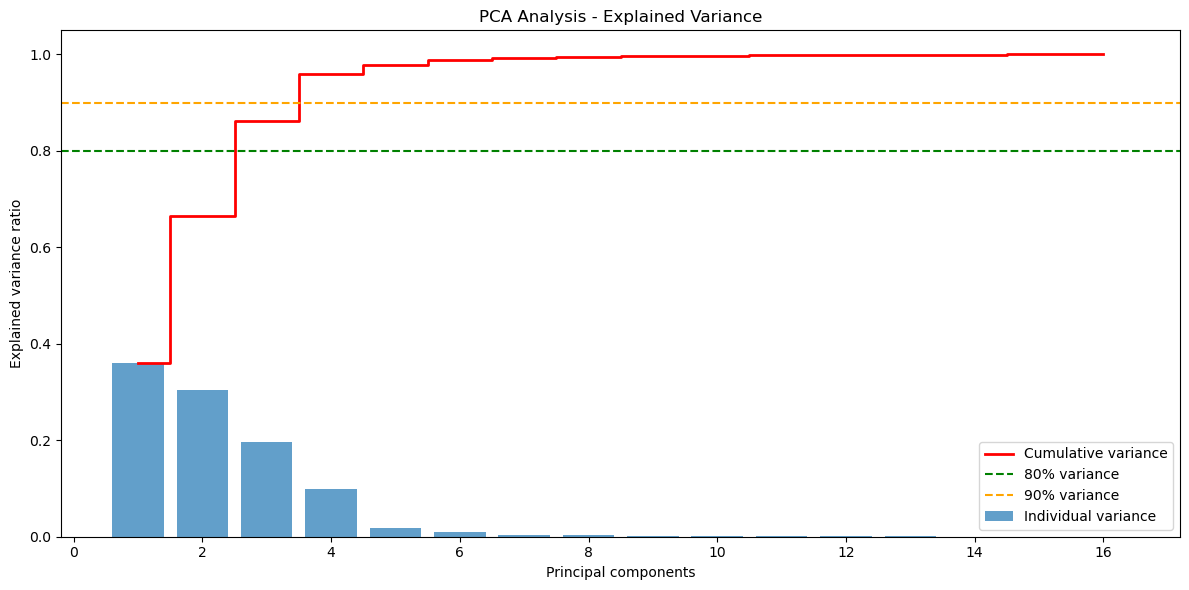


Cumulative variance:
PC1-PC1: 36.08%
PC1-PC2: 66.41%
PC1-PC3: 86.12%
PC1-PC4: 95.95%
PC1-PC5: 97.76%


In [ ]:
# Variance plot
analyzer.plot_pca_variance()

In [11]:
# Find the optimal number of clusters
optimal_result = analyzer.find_optimal_clusters()

In [12]:
optimal_result

{'k_range': [2, 3, 4, 5, 6, 7, 8, 9, 10],
 'inertias': [49268.180419827884,
  39564.84895481467,
  34368.17410268812,
  30772.091918673246,
  28317.00328575393,
  26659.68432262222,
  25180.21378443285,
  23911.198194534743,
  22795.926998447903],
 'silhouette_scores': [np.float64(0.20853439275314872),
  np.float64(0.23635517663737798),
  np.float64(0.23994952437809575),
  np.float64(0.2286507076358306),
  np.float64(0.1985363217906303),
  np.float64(0.1916976372788811),
  np.float64(0.19667781524304545),
  np.float64(0.1881786872363543),
  np.float64(0.18128097678688002)],
 'best_k_silhouette': 4}

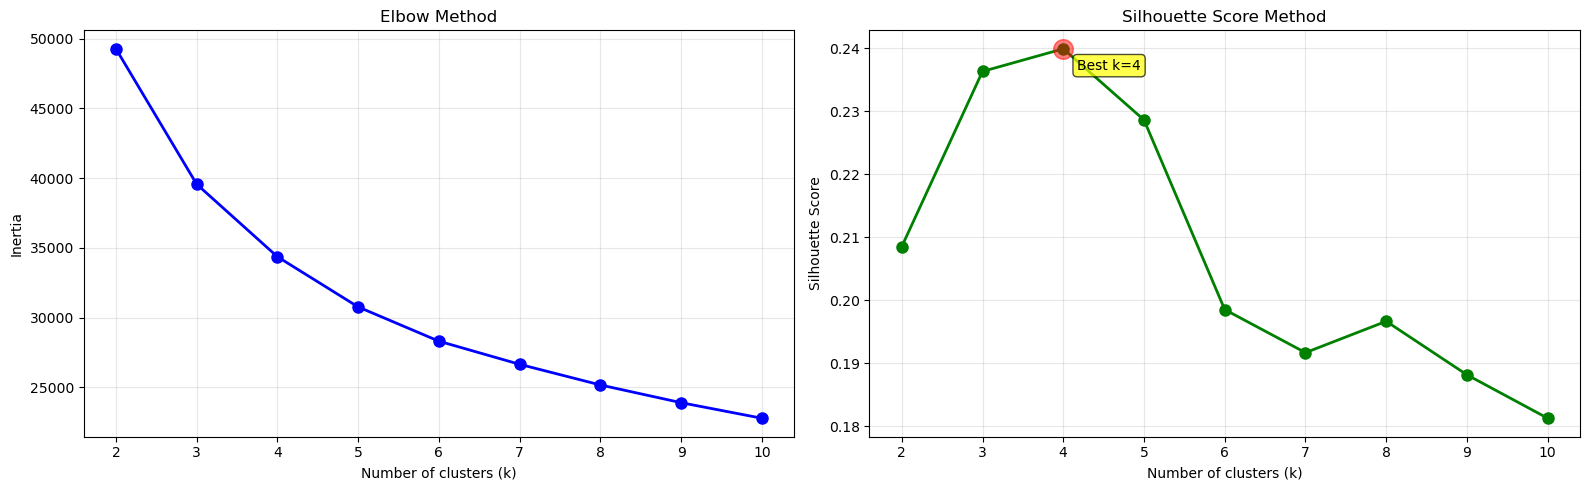

Silhouette Score recommendation: k=4 (score = 0.240)


In [14]:
analyzer.plot_optimal_clusters()

In [15]:
# Apply k-means
cluster_result = analyzer.apply_kmeans([3, 4])

Size of clusters (k=3):
0    1540
1    1512
2     869
Name: count, dtype: int64
Size of clusters (k=4):
0    1114
1     646
2    1319
3     842
Name: count, dtype: int64


In [17]:
type(cluster_result)

dict

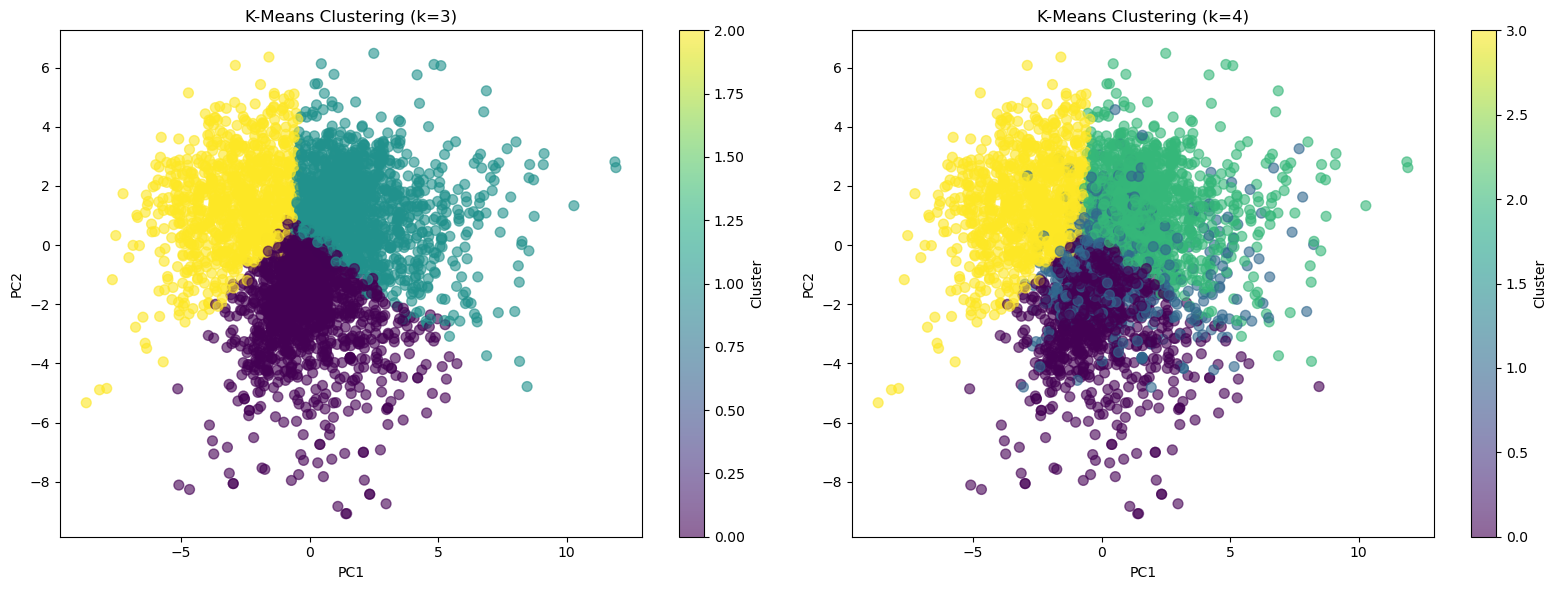

In [16]:
analyzer.plot_clusters_pca([3, 4])

In [18]:
cluster_means_3 = cluster_result[3]["means"]
cluster_means_4 = cluster_result[4]["means"]

display(cluster_means_3.round(2).style.background_gradient(cmap='viridis', axis=0))
display(cluster_means_4.round(2).style.background_gradient(cmap='viridis', axis=0))

,Sum_Quantity,Mean_UnitPrice,Mean_TotalPrice,Sum_TotalPrice,Count_Invoice,Count_Stock,Mean_InvoiceCountPerStock,Mean_StockCountPerInvoice,Mean_UnitPriceMeanPerInvoice,Mean_QuantitySumPerInvoice,Mean_TotalPriceMeanPerInvoice,Mean_TotalPriceSumPerInvoice,Mean_UnitPriceMeanPerStock,Mean_QuantitySumPerStock,Mean_TotalPriceMeanPerStock,Mean_TotalPriceSumPerStock
Cluster_3,,,,,,,,,,,,,,,,
0,181.160000,6.350000,33.980000,365.260000,1.680000,16.170000,1.080000,11.300000,6.860000,124.190000,35.750000,240.680000,6.340000,16.910000,33.440000,39.270000
1,2627.300000,3.590000,147.830000,5154.670000,8.310000,88.530000,1.520000,21.310000,4.280000,412.290000,173.230000,633.410000,3.810000,133.770000,145.770000,200.940000
2,472.870000,2.620000,6.290000,769.690000,3.300000,95.160000,1.220000,41.990000,2.770000,159.610000,7.110000,246.560000,2.630000,4.820000,6.250000,7.600000


,Sum_Quantity,Mean_UnitPrice,Mean_TotalPrice,Sum_TotalPrice,Count_Invoice,Count_Stock,Mean_InvoiceCountPerStock,Mean_StockCountPerInvoice,Mean_UnitPriceMeanPerInvoice,Mean_QuantitySumPerInvoice,Mean_TotalPriceMeanPerInvoice,Mean_TotalPriceSumPerInvoice,Mean_UnitPriceMeanPerStock,Mean_QuantitySumPerStock,Mean_TotalPriceMeanPerStock,Mean_TotalPriceSumPerStock,Cluster_3
Cluster_4,,,,,,,,,,,,,,,,,
0,165.100000,8.500000,46.000000,434.860000,1.770000,17.190000,1.090000,11.420000,9.190000,103.480000,48.160000,260.670000,8.490000,12.230000,45.310000,76.110000,0.000000
1,504.820000,1.670000,56.510000,481.830000,1.720000,18.050000,1.110000,12.720000,1.680000,303.770000,59.040000,312.390000,1.670000,85.710000,56.080000,68.500000,0.370000
2,2851.500000,3.570000,142.810000,5753.740000,9.230000,98.620000,1.560000,22.330000,4.380000,388.020000,170.950000,639.850000,3.810000,121.070000,140.600000,178.600000,1.000000
3,464.650000,2.650000,6.170000,760.490000,3.280000,95.670000,1.220000,42.400000,2.760000,154.420000,6.970000,245.220000,2.660000,4.540000,6.140000,7.470000,2.000000


By pasting the data to a LLM model and verify if it matches the data stats, we could get the cluster name

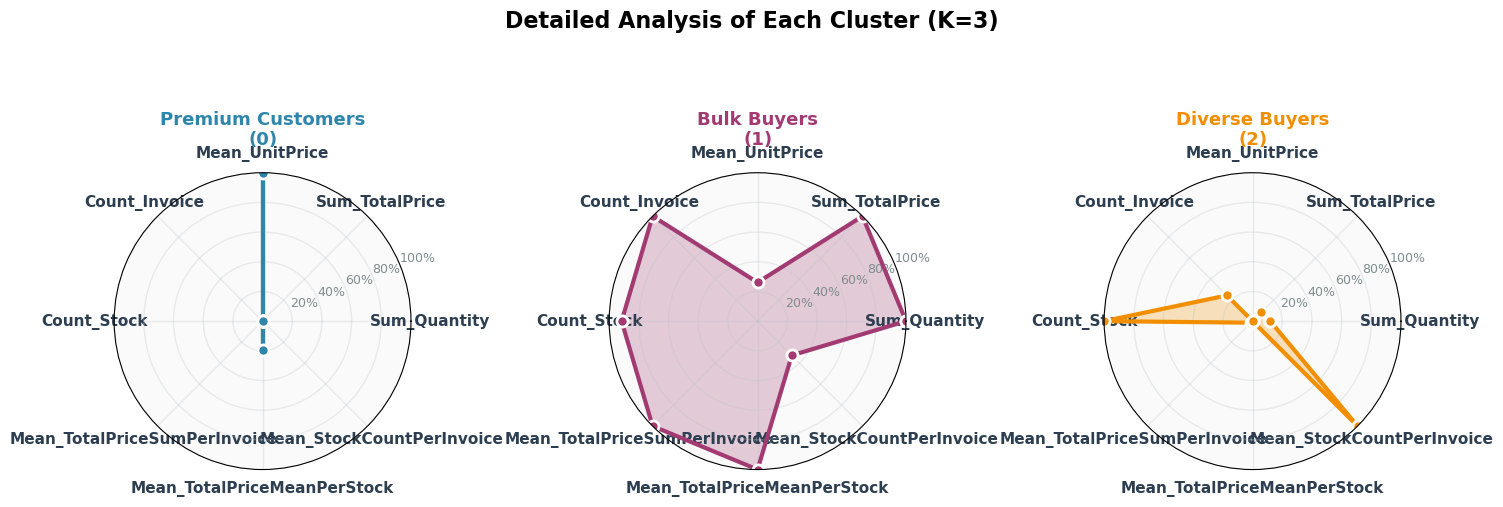

In [21]:
analyzer.create_individual_radar_plots(3, ['Premium Customers', 'Bulk Buyers', 'Diverse Buyers'])

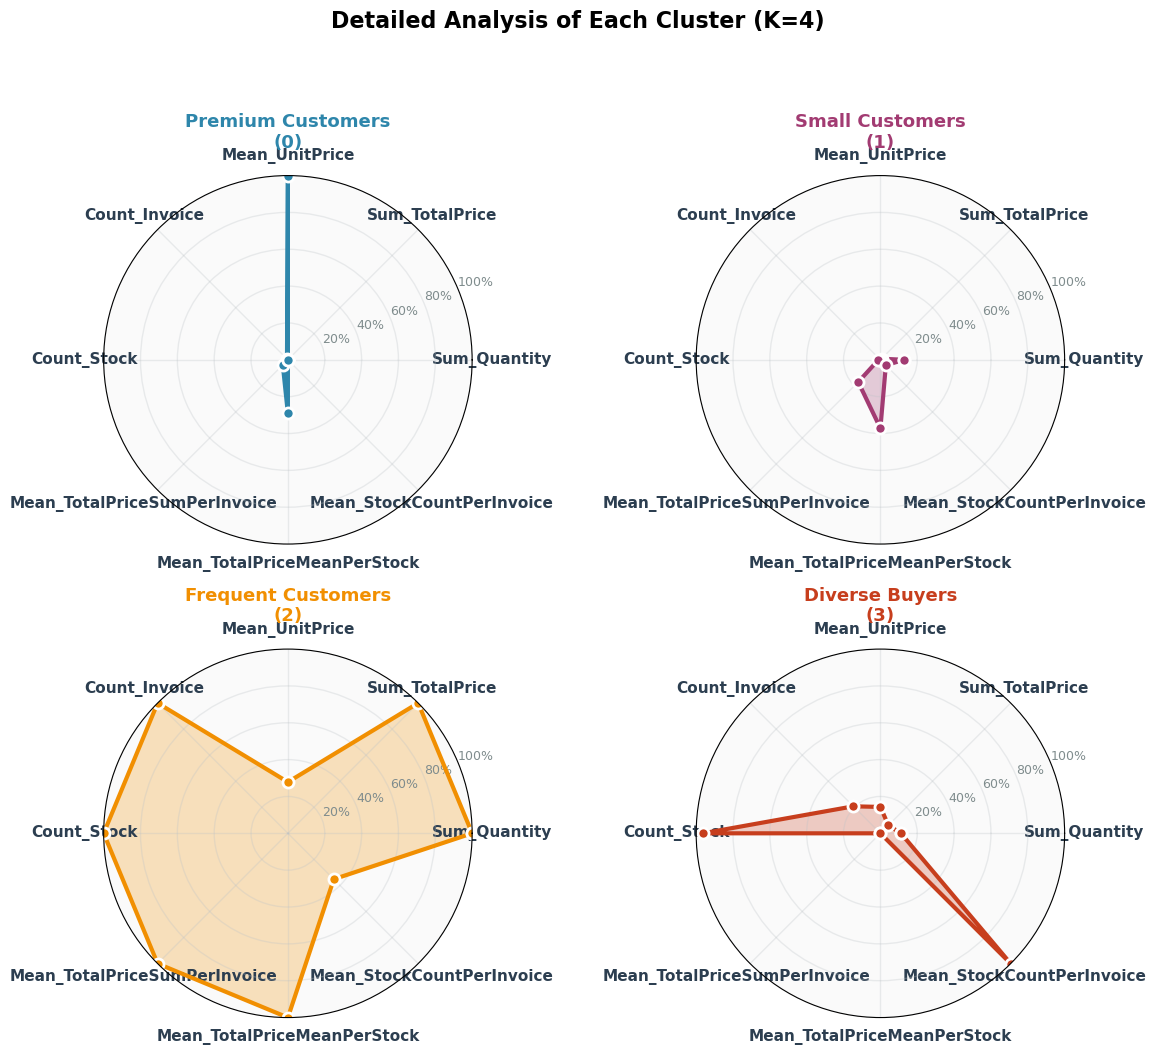

In [22]:
analyzer.create_individual_radar_plots(4, ['Premium Customers', 'Small Customers', 'Frequent Customers', 'Diverse Buyers'])